# BERT Embeddings & VADER Sentiment for Reddit Comments

This notebook uses BERT for tokenization and [CLS] embedding extraction, and VADER for 3-class sentiment analysis (positive/neutral/negative) on Reddit comment data from the Sentimentrix project.

## Goals:
1. Load Reddit comments data
2. Extract BERT [CLS] embeddings for each comment
3. Apply VADER 3-class sentiment labeling
4. Visualize VADER sentiment distribution

## Step 1: Import Required Libraries

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")

Device: CPU


## Step 2: Load Data

In [105]:
D_westernu_comments = pd.read_csv("../../dataset/reddit_data/WesternU_comments.csv")
print(f"Total comments: {len(D_westernu_comments)}")
display(D_westernu_comments.head())

Total comments: 47


,post_id,comment_id,comment_text,comment_score,comment_author,comment_created_utc,parent_id,reply_to_id,comment_sentiment,has_images,num_images,image_urls,subreddit
0,12p2lmp,kvayuwc,Meee I’m probably doing health sci,1,[deleted],1.710695e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
1,12p2lmp,jlprjaz,Hi,1,Purple_Character6184,1.685117e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
2,12dvo59,lm2j9yu,"Congrats! May I know your stats, like gpa and ...",1,Only_Researcher6011,1.725773e+09,t3_12dvo59,12dvo59,NaN,False,0,NaN,WesternU
3,ztfu7e,lm9oi3b,I am interested in!,1,Only_Researcher6011,1.725886e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU
4,ztfu7e,m7hxd3l,yes,1,Eastern-State6466,1.737054e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU


## Step 3: Data Preprocessing

In [106]:
# Data preprocessing with gentler filtering
# Minimum comment length to keep (set to 2 to avoid dropping short but valid comments)
MIN_LEN = 2

# Ensure text column exists; try common alternatives if not
text_col = None
for candidate in ['comment_text', 'body', 'text', 'commentBody']:
    if candidate in D_westernu_comments.columns:
        text_col = candidate
        break

if text_col is None:
    raise KeyError(f'No text column found in comments CSV. Columns: {D_westernu_comments.columns.tolist()}')

print('Using text column:', text_col)

# Create cleaned DataFrame
D_comments_clean = D_westernu_comments.dropna(subset=[text_col]).copy()
D_comments_clean[text_col] = D_comments_clean[text_col].astype(str).str.strip()
# Remove empty strings
D_comments_clean = D_comments_clean[D_comments_clean[text_col].str.len() >= MIN_LEN].copy()
# Rename to standard column used downstream
D_comments_clean = D_comments_clean.rename(columns={text_col: 'comment_text'})

print(f"Original rows: {len(D_westernu_comments)}, after dropna and min length ({MIN_LEN}): {len(D_comments_clean)}")
# show sample
display(D_comments_clean[['comment_id', 'comment_text']].head())

Using text column: comment_text
Original rows: 47, after dropna and min length (2): 47


,comment_id,comment_text
0,kvayuwc,Meee I’m probably doing health sci
1,jlprjaz,Hi
2,lm2j9yu,"Congrats! May I know your stats, like gpa and ..."
3,lm9oi3b,I am interested in!
4,m7hxd3l,yes


## Step 4: Initialize BERT Pipeline

In [ ]:
# (Skip BERT sentiment pipeline. Only use BERT for embeddings below.)
# This cell intentionally left blank or can be removed.

macOS with MPS detected — forcing CPU for compatibility
Device: cpu (pipeline device=-1)
Loading BERT model (this may take a moment)...
✓ BERT pipeline ready
✓ BERT pipeline ready


## Step 4b: Load BERT Tokenizer and Model for Embeddings

We'll use the BERT tokenizer and model to extract [CLS] embeddings for each comment. This will NOT perform sentiment classification, only feature extraction.

In [108]:
from transformers import BertTokenizer, BertModel
import torch

# Load BERT tokenizer and model
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)
bert_model.eval()
print(f"BERT model loaded on {device}")

BERT model loaded on cpu


In [109]:
# Extract [CLS] embeddings for all comments in batches
from tqdm.notebook import tqdm

BATCH_SIZE = 16
MAX_LENGTH = 128
texts = D_comments_clean['comment_text'].astype(str).tolist()
all_cls_embeddings = []

print(f"Extracting BERT [CLS] embeddings for {len(texts)} comments...")
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = bert_model(**inputs)
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_cls_embeddings.append(cls_emb)

# Concatenate all embeddings
import numpy as np
bert_cls_matrix = np.concatenate(all_cls_embeddings, axis=0)
print(f"bert_cls_matrix shape: {bert_cls_matrix.shape}")

# Optionally, add to DataFrame for downstream ML
# D_comments_clean['bert_cls_embedding'] = list(bert_cls_matrix)

Extracting BERT [CLS] embeddings for 47 comments...


  0%|          | 0/3 [00:00<?, ?it/s]

bert_cls_matrix shape: (47, 768)


## Step 5: VADER Sentiment Labeling

In [ ]:
# VADER sentiment labeling for all comments
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not isinstance(text, str):
        return 'neutral'
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

D_comments_clean['vader_sentiment'] = D_comments_clean['comment_text'].apply(get_vader_sentiment)
print(D_comments_clean['vader_sentiment'].value_counts())

Processing 47 comments in batches of 16...


  0%|          | 0/3 [00:00<?, ?it/s]

✓ BERT classification complete
bert_sentiment
negative    25
positive    22
Name: count, dtype: int64
Loading VADER labels from ../../dataset/reddit_data/WesternU_comments_vader_sentiment.csv
Saved BERT results to ../../dataset/reddit_data/WesternU_comments_bert_results.csv

VADER counts:

BERT counts:
bert_sentiment
negative    25
positive    22
Name: count, dtype: int64


## Step 6: Results (VADER Only)

In [ ]:
print("VADER Sentiment Distribution:")
print(D_comments_clean['vader_sentiment'].value_counts())

BERT Sentiment Distribution:
bert_sentiment
negative    25
positive    22
Name: count, dtype: int64

Average Confidence: 0.9614


## Step 7: Visualization (VADER Sentiment)

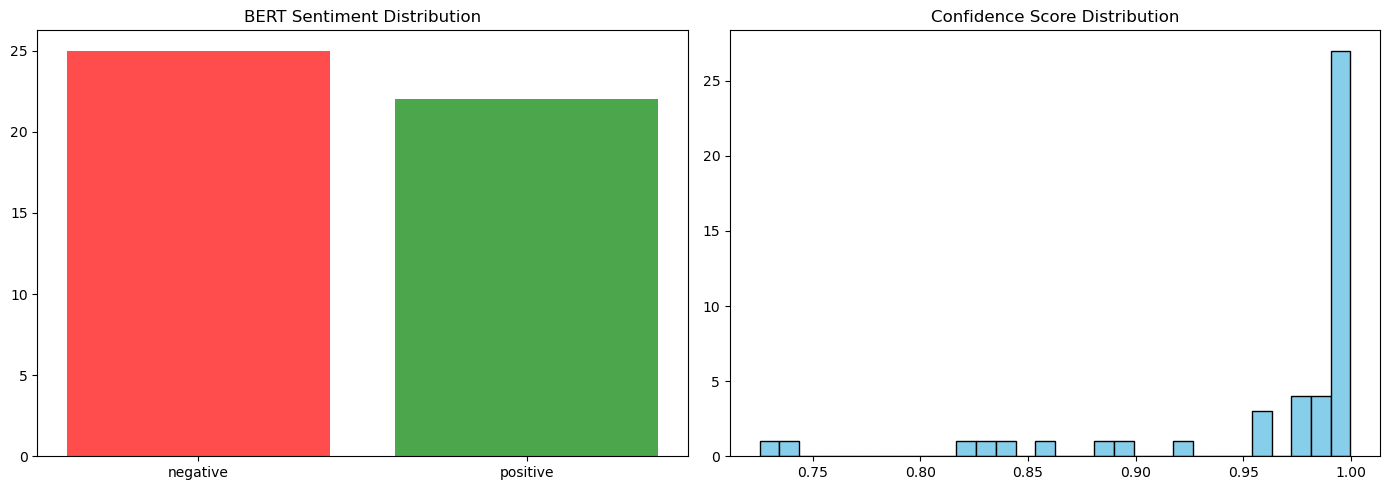

In [ ]:
# Visualize VADER sentiment distribution
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = D_comments_clean['vader_sentiment'].value_counts()
colors = ['green' if x == 'positive' else 'red' if x == 'negative' else 'gray' for x in sentiment_counts.index]
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)
plt.title('VADER Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()